# P05. Love Numbers with the Radial Solver

Tidal Love numbers describe a body's response to a tidal potential. $k$ scales the induced gravity potential, $h$ the radial surface displacement, and $l$ the tangential displacement. The 1D radial solver integrates the six-component $y$ system from the center to the surface, using each layer's density, complex moduli, and type, and finds the Love numbers from the surface boundary condition.

This notebook computes Love numbers for a layered terrestrial world, compressible vs. incompressible and static vs. dynamic (with or without the body's own inertia). It uses two methods: a shooting integrator for general compressible interiors, and a propagator matrix for the incompressible homogeneous limit, which is checked against a classical analytic result. The [Earth Love number benchmark](../../Benchmarks/RadialSolver/Earth_Love_Numbers.ipynb) and the [homogeneous viscoelastic benchmark](../../Benchmarks/RadialSolver/Homogeneous_Viscoelastic_Love_Numbers.ipynb) compare both methods against published values and closed forms.

In [1]:
%matplotlib inline
import copy

import numpy as np
import matplotlib.pyplot as plt

from TidalPy.constants import G
from TidalPy.RadialSolver import radial_solver, homogeneous_love_numbers
from TidalPy.Rheology import Maxwell, Elastic
from TidalPy.Structures import build_world


def solve_layers(radius, density, cbulk, cshear, freq, bulk_density, types, is_static, is_incompressible, upper_radii,
                 degree_l=2):
    "Run the radial solver for the tidal Love numbers and return (k, h, l, success)."
    solution = radial_solver(radius, density, cbulk, cshear, freq, bulk_density, types, is_static, is_incompressible,
                             upper_radii, degree_l=degree_l, solve_for=("tidal",))
    return solution.k, solution.h, solution.l, solution.success

## A Two-Layer Terrestrial World

A dense, stiff core under a rocky Maxwell mantle, forced at a one-day tidal period. The interface radius appears twice in the radius array, once as the top of the core and once as the base of the mantle. `bulk_density` is the mean density of this profile.

With the shooting (compressible) method, $k_2$ and $h_2$ come within about 10 percent of Earth's (about 0.30 and 0.61), but only because two errors offset: the solid core deforms far less than Earth's liquid outer core, and the mantle is soft (80 GPa, against 221 GPa in the bundled `earth_simple` used later). $l_2$ is twice Earth's 0.085 (Petit and Luzum 2010). The `earth_simple` world, with a liquid outer core, matches all three.

In [2]:
R = 6.371e6
R_core = 3.48e6
freq = 2.0 * np.pi / 86400.0     # one-day forcing

n_core = n_mantle = 80
radius = np.concatenate([np.linspace(0.0, R_core, n_core), np.linspace(R_core, R, n_mantle)])
in_core = np.arange(radius.size) < n_core

density = np.where(in_core, 10000.0, 4500.0)
bulk_density = (10000.0 * R_core**3 + 4500.0 * (R**3 - R_core**3)) / R**3   # Mean density of the profile [kg m-3]
shear = np.where(in_core, Elastic().calc_complex_modulus(200e9, 1e40, freq),
                          Maxwell().calc_complex_modulus(80e9, 1e21, freq))
bulk = np.where(in_core, 300.0e9 + 0j, 200.0e9 + 0j)
upper = np.array([R_core, R])
types = ("solid", "solid")

k, h, l, ok = solve_layers(radius, density, bulk, shear, freq, bulk_density,
                           types, (False, False), (False, False), upper)
print(f"bulk density = {bulk_density:.0f} kg m-3")
print(f"success = {ok}")
print(f"k2 = {k.real:+.4f} {k.imag:+.2e}j")
print(f"h2 = {h.real:+.4f}")
print(f"l2 = {l.real:+.4f}")

bulk density = 5396 kg m-3
success = True
k2 = +0.2746 -1.35e-07j
h2 = +0.5474
l2 = +0.1681


## Compressible vs Incompressible

For a homogeneous, incompressible sphere, $k_2$ has a classical closed form (Kelvin):

$$k_2 = \frac{3/2}{1 + \frac{19 \mu}{2 \rho g R}}$$

The propagator-matrix method reproduces it. Allowing compressibility (shooting method) raises $k_2$ slightly because the interior can also change volume.

In [3]:
N = 120
mu_h = Elastic().calc_complex_modulus(80.0e9, 1e40, freq)

# Propagation matrix method for the incompressible case, shooting method for the compressible one.
sol_i = homogeneous_love_numbers(R, bulk_density, mu_h, freq, num_slices=N,
                                 layer_is_incompressible=True, love_method='propagation_matrix')
sol_c = homogeneous_love_numbers(R, bulk_density, mu_h, freq, num_slices=N)

g_surf = G * bulk_density * (4.0 / 3.0) * np.pi * R
k_analytic = 1.5 / (1.0 + 19.0 * 80.0e9 / (2.0 * bulk_density * g_surf * R))

print(f"incompressible (propagator matrix): k2 = {sol_i.k.real:.5f}")
print(f"incompressible (analytic Kelvin)  : k2 = {k_analytic:.5f}")
print(f"compressible   (shooting)         : k2 = {sol_c.k.real:.5f}")

incompressible (propagator matrix): k2 = 0.45456
incompressible (analytic Kelvin)  : k2 = 0.45456
compressible   (shooting)         : k2 = 0.46158


## Static vs Dynamic

The dynamic solution includes the body's own inertia and the static solution does not. They agree at the long periods typical of tides and separate below a few hours, where inertia matters. There the dynamic $k_2$ passes through the body's degree-2 spheroidal free oscillations (normal modes). At a normal-mode period the forced response grows without bound, so $k_2$ jumps from large negative to large positive values; the plot clips these spikes. For comparison, Earth's gravest mode, $_0S_2$, has a period of 54 minutes.

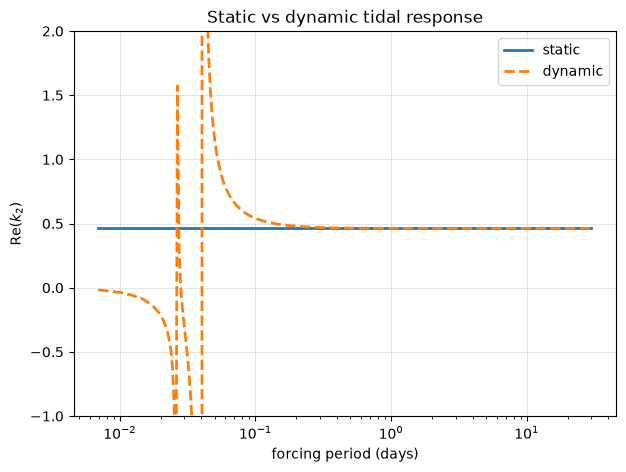

normal modes near 38, 58 minutes


In [4]:
periods_s = np.logspace(np.log10(600.0), np.log10(30.0 * 86400.0), 300)   # 10 min to 30 days
k_static, k_dynamic = [], []
for p in periods_s:
    w = 2.0 * np.pi / p
    mu = Maxwell().calc_complex_modulus(80.0e9, 1.0e21, w)
    sol_s = homogeneous_love_numbers(R, bulk_density, mu, w, num_slices=N)
    sol_d = homogeneous_love_numbers(R, bulk_density, mu, w, num_slices=N, layer_is_static=False)
    k_static.append(sol_s.k.real)
    k_dynamic.append(sol_d.k.real)
k_static, k_dynamic = np.array(k_static), np.array(k_dynamic)

fig, ax = plt.subplots(figsize=(7, 5))
ax.semilogx(periods_s / 86400.0, k_static, lw=2, label="static")
ax.semilogx(periods_s / 86400.0, k_dynamic, "--", lw=2, label="dynamic")
ax.set_ylim(-1.0, 2.0)   # Clip the normal-mode spikes
ax.set_xlabel("forcing period (days)")
ax.set_ylabel(r"Re$(k_2)$")
ax.set_title("Static vs dynamic tidal response")
ax.legend(); ax.grid(alpha=0.3)
plt.show()

# A normal mode sits where the dynamic k2 jumps from large negative to large positive values
modes = np.flatnonzero((k_dynamic[:-1] < -1.0) & (k_dynamic[1:] > 1.0))
print("normal modes near", ", ".join(f"{np.sqrt(periods_s[i] * periods_s[i + 1]) / 60.0:.0f}" for i in modes),
      "minutes")

## Degree Dependence

Tides of higher harmonic degree $l$ probe shallower depths and give smaller Love numbers. The two-layer world's $k_l$ falls off quickly with $l$.

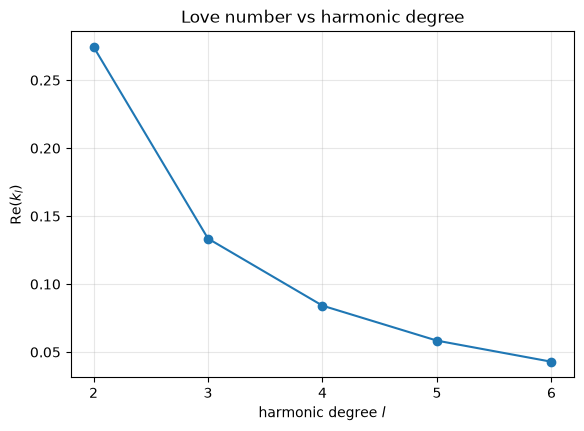

  l=2:  k = 0.2746
  l=3:  k = 0.1335
  l=4:  k = 0.0841
  l=5:  k = 0.0584
  l=6:  k = 0.0429


In [5]:
degrees = [2, 3, 4, 5, 6]
kl = []
for L in degrees:
    kL, *_ = solve_layers(radius, density, bulk, shear, freq, bulk_density,
                          types, (False, False), (False, False), upper, degree_l=L)
    kl.append(kL.real)

fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.plot(degrees, kl, "o-")
ax.set_xticks(degrees)
ax.set_xlabel("harmonic degree $l$")
ax.set_ylabel(r"Re$(k_l)$")
ax.set_title("Love number vs harmonic degree")
ax.grid(alpha=0.3)
plt.show()
for L, v in zip(degrees, kl):
    print(f"  l={L}:  k = {v:.4f}")

## Love Numbers on a Built World

The examples above pass arrays directly to `radial_solver`. A built world (from a bundled name, a TOML file, or a dict) stores the same information in its layers. `solve_eos()` integrates the structure once. `solve_love_numbers(frequency, degree_l)` then evaluates each layer's rheology at the forcing frequency \[rad s$^{-1}$\] and solves the radial problem.

The bundled `earth_simple` world has a solid inner core, a static liquid outer core, and an Andrade mantle. Its mantle shear modulus is fitted to $k_2 = 0.30$ at the semidiurnal M2 period (12.4206 hours).

The call returns a dict and stores the results on the world:

- `love_number_k`, `love_number_h`, `love_number_l`: Complex Love numbers.
- `love_success`: Whether the solve converged.
- `love_q_k` and `love_lag_k`: The quality factor $Q = -s\,|k| / \mathrm{Im}(k)$, with $s$ the sign of $\mathrm{Re}(k)$, and the phase lag \[rad\] of $k$.
- `love_surface_amplification`: Conditioning of the surface boundary-condition solve. Values near 1 are healthy.
- `love_effective_shear_modulus`: Averaged shear modulus \[Pa\] used by the analytic methods in the next section. NaN after a radial-solver solve.

In [6]:
# Build the bundled three-layer Earth and solve its structure once
earth = build_world("earth_simple")
earth.solve_eos(raise_on_fail=True)

freq_m2 = 2.0 * np.pi / (12.4206 * 3600.0)   # M2 forcing frequency [rad s-1]

# Tidal Love numbers with the world's configured method (radial_solver by default)
result = earth.solve_love_numbers(
    frequency=freq_m2,
    degree_l=2)

print(f"method                  = {earth.love_method}")
print(f"success                 = {earth.love_success}")
print(f"k2                      = {earth.love_number_k:.5f}")
print(f"h2                      = {earth.love_number_h:.5f}")
print(f"l2                      = {earth.love_number_l:.5f}")
print(f"Q of k2                 = {earth.love_q_k:.1f}")
print(f"lag of k2               = {np.degrees(earth.love_lag_k):.3f} deg")
print(f"surface amplification   = {earth.love_surface_amplification:.3f}")
print(f"result dict keys        = {list(result)}")

method                  = radial_solver
success                 = True
k2                      = 0.29996-0.00122j
h2                      = 0.63019-0.00224j
l2                      = 0.07543-0.00053j
Q of k2                 = 246.3
lag of k2               = 0.233 deg
surface amplification   = 3.228
result dict keys        = ['success', 'error_code', 'message', 'love_method', 'love_number_k', 'love_number_h', 'love_number_l']


## Love Methods on the Same World

`love_method` selects how the Love numbers are calculated. Pass it per call, or set the world default with `set_tide_config(love_method=...)` or the `love_method` key of the `[tides]` table.

- `radial_solver`: Integrates the radial equations through every layer. Use it for layered interiors, liquid layers, and depth-dependent moduli.
- `homogeneous`: Treats each layer with `use_tides` on as a homogeneous planet (the planet's radius, bulk density, and surface gravity, with the layer's volume-averaged moduli and log-volume-averaged viscosity). It then sums the layers' Love numbers weighted by `tidal_scale` (the layer's volume fraction unless set). This quick estimate ignores how the layers deform together. Here the liquid outer core has `use_tides` off and adds nothing, so the result is about 0.84 (the mantle's `tidal_scale`, printed below) times the $k_2$ of a homogeneous planet with the mantle's moduli, and it misses the extra deformation the liquid core allows. `love_effective_shear_modulus` reports the scale-weighted mean modulus.
- `cpl` and `ctl`: Same construction, with each layer's static shear modulus giving $\mathrm{Re}(k_2)$. Then $-\mathrm{Im}(k_2) = \mathrm{Re}(k_2)/Q$ (constant phase lag) or $\mathrm{Re}(k_2)\,\omega\,\Delta t$ (constant time lag, $\Delta t$ \[s\]). $Q$ and $\Delta t$ are taken, in order, from the call (`fixed_q`, `fixed_dt`), from `set_tide_config(love_fixed_q=..., love_fixed_dt=...)` or the `[tides]` keys `love_fixed_q` and `love_fixed_dt_s`, and from the attached tide model. A `ValueError` is raised if none of these supplies a value.
- `propagation_matrix`: Valid only for a single solid, static, incompressible layer. On this three-layer world it sets `love_success = False` and gives the reason in `love_message` instead of raising an error.

In [7]:
# Each method on the same solved world at the M2 frequency
method_settings = [
    ("radial_solver", {}),
    ("homogeneous", {}),
    ("cpl", {"fixed_q": 100.0}),          # constant phase lag with Q = 100
    ("ctl", {"fixed_dt": 600.0}),         # constant time lag of 600 s
    ("propagation_matrix", {}),
]

print(f"{'method':<20}{'success':>8}{'Re(k2)':>10}{'-Im(k2)':>11}{'Re(h2)':>9}{'mu_eff [GPa]':>22}")
for method, settings in method_settings:
    earth.solve_love_numbers(
        frequency=freq_m2,
        degree_l=2,
        love_method=method,
        **settings)
    k_method = earth.love_number_k if earth.love_success else complex(np.nan, np.nan)
    # The averaged modulus is only defined for the analytic methods
    if method in ("homogeneous", "cpl", "ctl"):
        mu_eff = f"{earth.love_effective_shear_modulus / 1.0e9:.2f}"
    else:
        mu_eff = "-"
    print(f"{method:<20}{str(earth.love_success):>8}{k_method.real:>10.4f}{-k_method.imag:>11.2e}"
          f"{earth.love_number_h.real:>9.4f}{mu_eff:>22}")

print()
print("propagation_matrix message:", earth.love_message)
print(f"mantle tidal_scale = {earth.get_layer_tidal_scale('mantle'):.3f}")

method               success    Re(k2)    -Im(k2)   Re(h2)          mu_eff [GPa]
radial_solver           True    0.3000   1.22e-03   0.6302                     -
homogeneous             True    0.1836   1.12e-03   0.3060          216.54+1.58j
cpl                     True    0.1814   1.81e-03   0.3024          219.69+0.00j
ctl                     True    0.1814   1.53e-02   0.3024          219.69+0.00j
propagation_matrix     False       nan        nan      nan                     -

propagation_matrix message: TidalPy: the propagation-matrix method requires a single solid, static, incompressible layer.
mantle tidal_scale = 0.837


## Tidal, Loading, and Free Love Numbers

`solve_for` selects the surface boundary condition, as one name or a tuple, in both `solve_love_numbers` and `radial_solver`. A tuple solves every condition from one integration. `get_love_number_k(i)` (and the `_h` and `_l` versions) read condition `i` in the order requested. The `love_number_*` properties report the first.

- `tidal`: Response to an external tidal potential.
- `loading`: Response to a surface mass load of the same degree. The load depresses the surface ($h' < 0$), and the displaced interior mass partly offsets the load's own potential ($k' < 0$).
- `free`: Stress-free surface with no forcing. Away from a normal-mode frequency its only solution is $y = 0$, giving $k = -1$ and $h = l = 0$. It is used to search for free oscillations, not to describe a forced response.

In [8]:
# All three boundary conditions from one integration
boundary_conditions = ("tidal", "loading", "free")
earth.solve_love_numbers(
    frequency=freq_m2,
    degree_l=2,
    love_method="radial_solver",
    solve_for=boundary_conditions)

print(f"number of solved conditions = {earth.love_num_ytypes}")
print(f"{'condition':<10}{'k2':>26}{'h2':>26}{'l2':>26}")
for ytype_idx, condition in enumerate(boundary_conditions):
    k_bc = earth.get_love_number_k(ytype_idx)
    h_bc = earth.get_love_number_h(ytype_idx)
    l_bc = earth.get_love_number_l(ytype_idx)
    print(f"{condition:<10}{k_bc:>26.5f}{h_bc:>26.5f}{l_bc:>26.5f}")

number of solved conditions = 3
condition                         k2                        h2                        l2
tidal               0.29996-0.00122j          0.63019-0.00224j          0.07543-0.00053j
loading            -0.33023+0.00102j         -1.04879+0.00210j          0.04880+0.00052j
free               -1.00000+0.00000j          0.00000+0.00000j          0.00000+0.00000j


## Radial Functions from a World Solve

`get_love_radial_y(radius, ytype_idx, y_idx)` evaluates the last radial solve at any radius \[m\], a float or an array, using the solver's dense output. `y_idx` 0 to 5 selects $y_1$ to $y_6$, and `ytype_idx` selects the boundary condition in the order requested. The six functions are the radial and tangential displacements ($y_1$, $y_3$), the matching stresses ($y_2$, $y_4$), and the potential perturbation and its gradient term ($y_5$, $y_6$). They are scaled to a unit forcing potential (1 m$^2$ s$^{-2}$) at the surface, so $y_5(R) = 1 + k$, $y_1$ and $y_3$ are in s$^2$ m$^{-1}$, $y_2$ and $y_4$ in kg m$^{-3}$, and $y_6$ in m$^{-1}$.

The static liquid outer core carries only the potential, so the displacements and stresses are NaN there and those curves break between 1221.5 and 3480 km. Values below the solver's starting radius near the center are also NaN. In the loading solution the potential nearly cancels inside the core: the load's own potential is offset by that of the depressed surface and core-mantle boundary, so $y_5$ stays below 0.001 there and the inner core barely deforms.

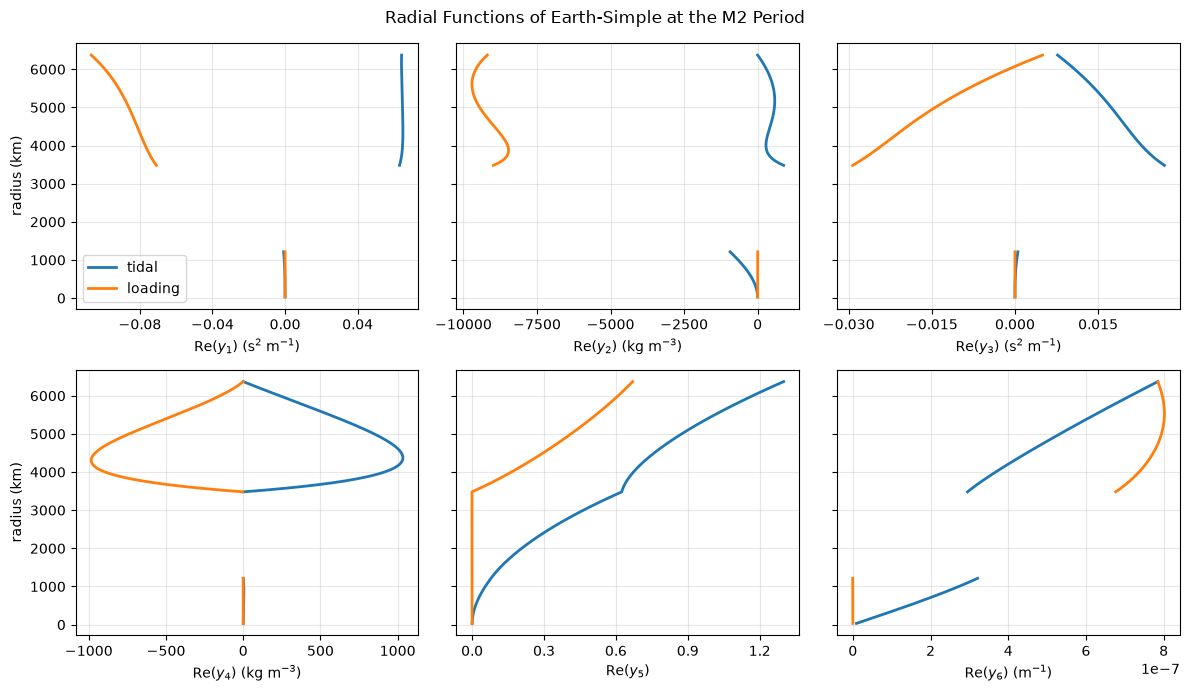

In [9]:
# Tidal and loading solutions from the solve above, sampled over the full radius
radii = np.linspace(1.0, 6.371e6, 400)   # [m]
y_labels = [r"Re($y_1$) (s$^2$ m$^{-1}$)", r"Re($y_2$) (kg m$^{-3}$)", r"Re($y_3$) (s$^2$ m$^{-1}$)",
            r"Re($y_4$) (kg m$^{-3}$)", r"Re($y_5$)", r"Re($y_6$) (m$^{-1}$)"]

fig, axes = plt.subplots(2, 3, figsize=(12, 7), sharey=True)
for y_idx, ax in enumerate(axes.flat):
    for ytype_idx, condition in enumerate(("tidal", "loading")):
        y_values = earth.get_love_radial_y(radii, ytype_idx, y_idx)
        ax.plot(y_values.real, radii / 1.0e3, lw=2, label=condition)
    ax.set_xlabel(y_labels[y_idx])
    ax.xaxis.set_major_locator(plt.MaxNLocator(5))   # Avoid overlapping tick labels
    ax.grid(alpha=0.3)
for ax in axes[:, 0]:
    ax.set_ylabel("radius (km)")
axes[0, 0].legend()
fig.suptitle("Radial Functions of Earth-Simple at the M2 Period")
fig.tight_layout()
plt.show()

## Solution Diagnostics

The standalone `radial_solver` returns a `RadialSolverSolution` with more diagnostics than the world properties. Below, the two-layer world from the start of this notebook is solved for the tidal and loading conditions together, so `Q_k` and `lag_k` have one entry per condition:

- `Q_k`: Effective quality factor, $-s\,|k| / \mathrm{Im}(k)$, with $s$ the sign of $\mathrm{Re}(k)$. A loading $k'$ is negative and its imaginary part positive, so the sign $s$ keeps `Q_k` positive for a dissipative response of either kind.
- `lag_k`: Phase lag \[rad\], $\arctan(-s\,\mathrm{Im}(k) / |\mathrm{Re}(k)|)$.
- `surface_solve_amplification`: Same conditioning measure as `love_surface_amplification` above.

`print_diagnostics()` summarizes the equation of state and radial solves; its pressure error is the remaining surface-pressure mismatch \[Pa\]. `plot_interior()` plots gravity, density, pressure, and the moduli against radius and returns the figure and axes. It calls `plt.show()` unless `show_plot=False`.

k2 (tidal, loading)         = [ 0.27459857-1.35198396e-07j -0.27283391+1.22215775e-07j]
Q_k                         = [2031078.64193552 2232395.21216468]
lag_k [rad]                 = [4.92349227e-07 4.47949357e-07]
surface solve amplification = 1.951

	Equation of State Solver:
		Success:           True
		Error code:        0
		Message:           Equation of state solver finished without issue.
		Iterations:        2
		Pressure Error:    8.255e-05 Pa
		Central Pressure:  2.879e+11 Pa
		Mass:              5.845e+24 kg
		MOI:               8.384e+37 kg m2 (factor 0.3534, sphere ratio 0.8835)
		Surface gravity:   9.612e+00 m s-2

	Radial Solver Results:
		Success:     True
		Error code:  0
		Message:     RadialSolver.ShootingMethod: Completed without any noted issues.
		Steps Taken (per sub-solution):
			Layer 0 = [24 17 22]
			Layer 1 = [6 5 6]
		Surface solve amplification:  1.951e+00
		Surface solve rcond:          1.434e-01
		k_2 = [ 0.27459857-1.35198396e-07j -0.27283391+1.22215775e

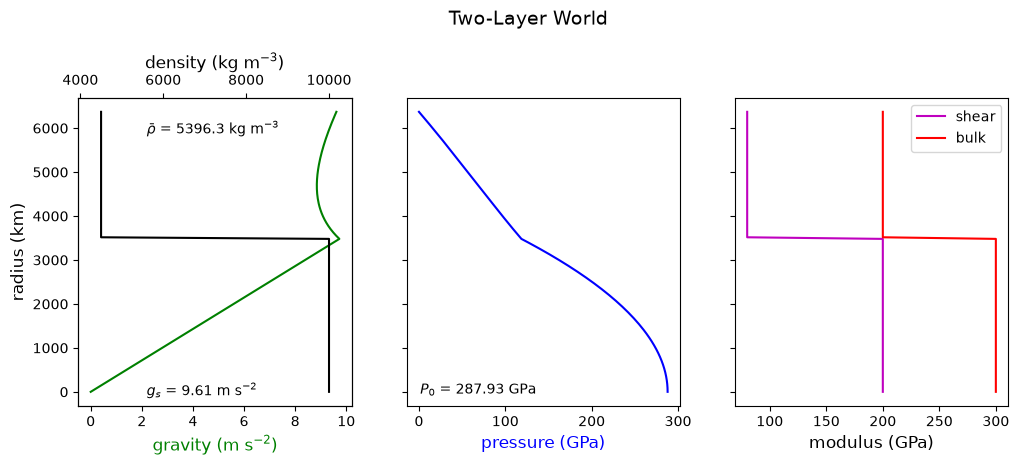

In [10]:
# Standalone solve of the two-layer world, tidal and loading together
solution = radial_solver(
    radius,
    density,
    bulk,
    shear,
    freq,
    bulk_density,
    types,
    (False, False),
    (False, False),
    upper,
    degree_l=2,
    solve_for=("tidal", "loading"))

print(f"k2 (tidal, loading)         = {solution.k}")
print(f"Q_k                         = {solution.Q_k}")
print(f"lag_k [rad]                 = {solution.lag_k}")
print(f"surface solve amplification = {solution.surface_solve_amplification:.3f}")
solution.print_diagnostics()

# Plot the equation of state results
fig, axes = solution.plot_interior(planet_name="Two-Layer World")

## Frequency Dependence

Each layer's rheology makes the complex Love number depend on the forcing frequency. `calc_love_numbers(frequencies, ...)` runs one solve per frequency and returns the Love numbers as arrays, with NaN wherever a solve fails. The sweep below covers forcing periods from 1 hour to 100,000 years for `earth_simple` and for a copy with a Maxwell mantle. The copy is built from `earth.get_config_dict()` with the mantle's `shear_rheology` table replaced.

The mantle viscosity of $10^{21}$ \[Pa s\] and shear modulus of $2.2 \times 10^{11}$ \[Pa\] give a Maxwell time of approx. 140 years. Well below that period, the Maxwell mantle is nearly elastic and its $-\mathrm{Im}(k_2)$ grows in proportion to the period. It peaks near 3,000 years, about 20 times the Maxwell time, because the planet's self-gravity also sets how fast it relaxes (the [homogeneous viscoelastic benchmark](../../Benchmarks/RadialSolver/Homogeneous_Viscoelastic_Love_Numbers.ipynb) shows the closed form). At longer periods the mantle relaxes like a fluid, $\mathrm{Re}(k_2)$ rises toward 0.93, and the loss falls again. Andrade transient creep adds dissipation across the tidal band, so the Andrade $-\mathrm{Im}(k_2)$ is several orders of magnitude larger at the M2 period and grows more slowly with period. Each solve reuses the cached structure, so both sweeps take well under a second.

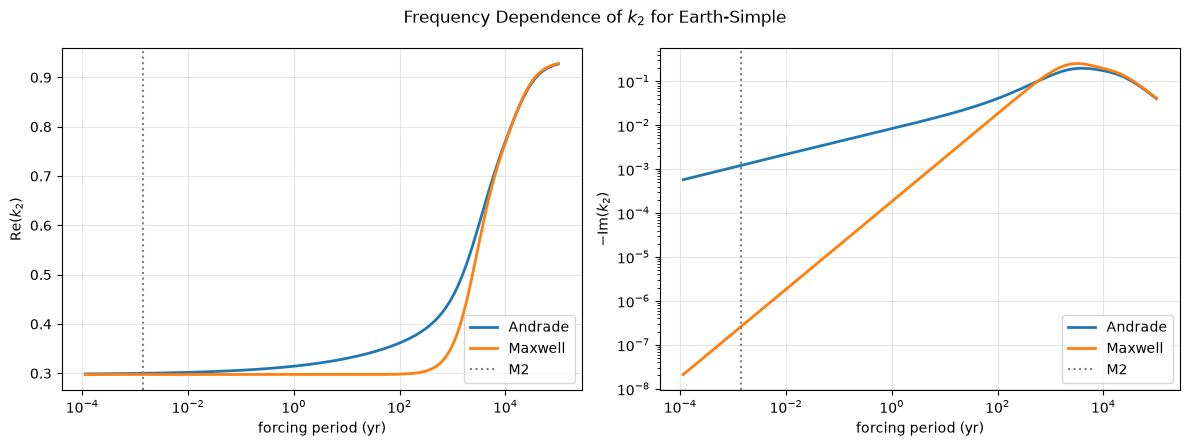

Andrade  k2 at 1 hr = 2.987e-01-5.749e-04j, at M2 = 3.000e-01-1.218e-03j, at 1e5 yr = 9.271e-01-4.033e-02j; largest -Im(k2) = 0.198 at 3926 yr
Maxwell  k2 at 1 hr = 2.976e-01-2.106e-08j, at M2 = 2.976e-01-2.616e-07j, at 1e5 yr = 9.281e-01-4.123e-02j; largest -Im(k2) = 0.253 at 3030 yr


In [11]:
# A Maxwell-mantle copy of Earth-Simple built from a config dict
maxwell_config = copy.deepcopy(earth.get_config_dict())
maxwell_config["name"] = "Earth-Simple-Maxwell"
maxwell_config["layers"]["mantle"]["shear_rheology"] = {"model": "maxwell"}
earth_maxwell = build_world(maxwell_config)
earth_maxwell.solve_eos(raise_on_fail=True)

year = 365.25 * 86400.0   # [s]
period_m2 = 12.4206 * 3600.0   # [s]
# 1 hour to 100,000 years [s], with the M2 period included
periods = np.sort(np.append(np.logspace(np.log10(3600.0), np.log10(1.0e5 * year), 160), period_m2))

k2_sweeps = {}
for label, world in (("Andrade", earth), ("Maxwell", earth_maxwell)):
    k2_sweeps[label] = world.calc_love_numbers(2.0 * np.pi / periods, degree_l=2, love_method="radial_solver")["k"]

fig, (ax_real, ax_imag) = plt.subplots(1, 2, figsize=(12, 4.5))
for label, k2_values in k2_sweeps.items():
    ax_real.semilogx(periods / year, k2_values.real, lw=2, label=label)
    ax_imag.loglog(periods / year, -k2_values.imag, lw=2, label=label)
for ax in (ax_real, ax_imag):
    ax.axvline(period_m2 / year, color="gray", ls=":", label="M2")
    ax.set_xlabel("forcing period (yr)")
    ax.grid(alpha=0.3)
    ax.legend()
ax_real.set_ylabel(r"Re$(k_2)$")
ax_imag.set_ylabel(r"$-$Im$(k_2)$")
fig.suptitle("Frequency Dependence of $k_2$ for Earth-Simple")
fig.tight_layout()
plt.show()

m2_idx = np.flatnonzero(periods == period_m2)[0]
for label, k2_values in k2_sweeps.items():
    peak_idx = np.nanargmax(-k2_values.imag)
    print(f"{label:<8} k2 at 1 hr = {k2_values[0]:.3e}, at M2 = {k2_values[m2_idx]:.3e}, "
          f"at 1e5 yr = {k2_values[-1]:.3e}; largest -Im(k2) = {-k2_values[peak_idx].imag:.3f} "
          f"at {periods[peak_idx] / year:.0f} yr")